Dataset loaded successfully!

   MODEL PERFORMANCE REPORT
Accuracy:        0.8340
ROC-AUC:         0.9222
MAE:             0.2089  (Lower is better)
SSE:             229.7041  (Lower is better)
MSE:             0.1149
RMSE:            0.3389
------------------------------

Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91      1970
           1       0.07      0.83      0.13        30

    accuracy                           0.83      2000
   macro avg       0.53      0.83      0.52      2000
weighted avg       0.98      0.83      0.90      2000


--- Transparency: Feature Impact ---
High Impact Score = Stronger Indicator of Fraud
                         Feature  Impact_Score
3              velocity_last_24h      1.085229
0                         amount      0.456146
7         merchant_category_Food     -0.076398
8      merchant_category_Grocery     -0.097746
4                 cardholder_age     -0.114616

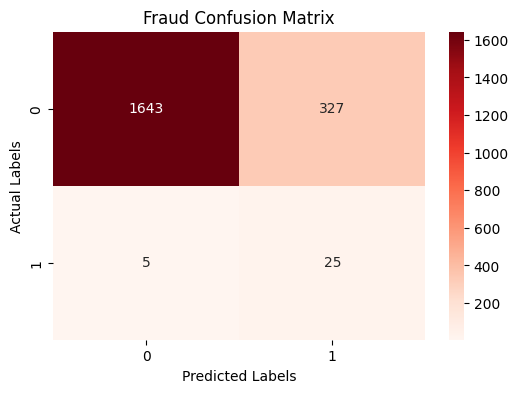

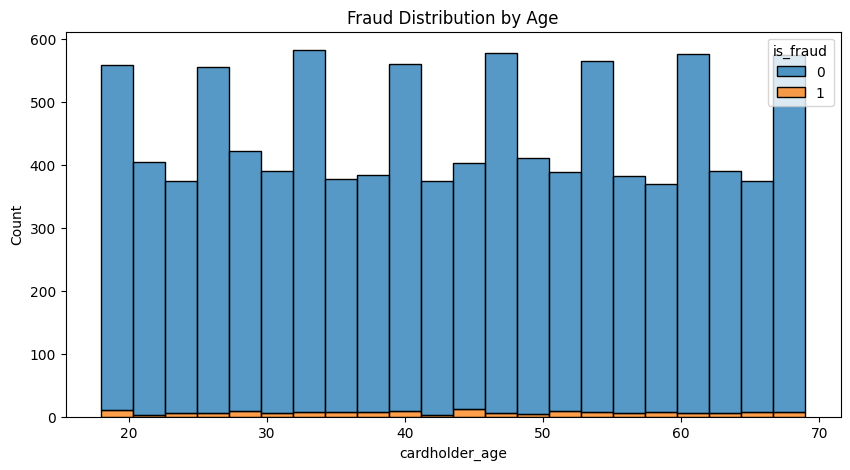

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics for both Classification and "Regression-style" error analysis
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    mean_absolute_error, mean_squared_error, accuracy_score
)

# 1. Load the dataset 
# Ensure fraud_data.csv is in the same folder as this notebook
try:
    df = pd.read_csv('credit.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: 'fraud_data.csv' not found. Please place it in the same folder.")

# 2. Data Preprocessing
X = df.drop(['transaction_id', 'is_fraud'], axis=1)
y = df['is_fraud']

# Define which columns are numbers and which are categories
numeric_features = ['amount', 'transaction_hour', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']
categorical_features = ['merchant_category']

# Define transformations (Standardization for numbers, OneHot for categories)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 3. Model Pipeline
# class_weight='balanced' handles the rare nature of fraud
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', solver='liblinear'))
])

# 4. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Train the model
model_pipeline.fit(X_train, y_train)

# 6. Generate Predictions and Probabilities
y_pred = model_pipeline.predict(X_test)
y_probs = model_pipeline.predict_proba(X_test)[:, 1] # Probability of being Fraud (class 1)

# 7. Metrics Calculation
# --- Classification Metrics ---
acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_probs)

# --- "Regression-style" Metrics (requested by user) ---
# MAE: Average absolute difference between predicted probability and actual (0 or 1)
mae = mean_absolute_error(y_test, y_probs)

# MSE: Mean Squared Error
mse = mean_squared_error(y_test, y_probs)

# SSE: Sum of Squared Errors
sse = np.sum((y_test - y_probs)**2)

# RMSE: Root Mean Squared Error
rmse = np.sqrt(mse)

print("\n" + "="*30)
print("   MODEL PERFORMANCE REPORT")
print("="*30)
print(f"Accuracy:        {acc:.4f}")
print(f"ROC-AUC:         {roc:.4f}")
print(f"MAE:             {mae:.4f}  (Lower is better)")
print(f"SSE:             {sse:.4f}  (Lower is better)")
print(f"MSE:             {mse:.4f}")
print(f"RMSE:            {rmse:.4f}")
print("-" * 30)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# 8. Transparency: Feature Importance
# Let's see what features the model thinks are the "Red Flags"
feature_names = numeric_features + list(model_pipeline.named_steps['preprocessor']
                                        .named_transformers_['cat']
                                        .get_feature_names_out(categorical_features))

coefs = model_pipeline.named_steps['classifier'].coef_[0]
importance_df = pd.DataFrame({'Feature': feature_names, 'Impact_Score': coefs})
importance_df = importance_df.sort_values(by='Impact_Score', ascending=False)

print("\n--- Transparency: Feature Impact ---")
print("High Impact Score = Stronger Indicator of Fraud")
print(importance_df.head(10))

# 9. Visualization: Confusion Matrix (Robustness Check)
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Fraud Confusion Matrix')
plt.show()


# 10. Fairness Analysis (Basic Age Group check)
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='cardholder_age', hue='is_fraud', multiple="stack")
plt.title("Fraud Distribution by Age")
plt.show()